# Echo energy only optimisation Scenario example
An example of defining an echo scenario that does not need a network model and which can have an arbitrary number of sites to be optimised. Most of this is the same as the scenario_example except that no network file is passed to teh scenario creation and the optional parameter energy_only is set to true

Each site has psuedo random assets (battery, evs, pv) at each site.

Features yet to come:
- export of results to data frame (currently have to query the list of dictionaries at scenario.sites for most things
- power available of V2G chargers to provide grid services

First we will define the percentages of DER penetration we want so that when we define the sites we can add the appropriate amounts

In [6]:
pv_percent = 0.5                    # percentage of sites with PV (0-1)
bat_percent = 0.5                   # percentage of sites with battery (0-1)
ev_percent = 0.5                    # percentage of sites with evs (0-1)
ev_mean = 2                         # mean number of evs per site

# Create the scenario
Create a scenario object of class EchoScenario. The description string is used to keep details such as percentages of DER. When creating the scenario object the file path to the network data is passed. This is read in using SGT and connection point information extracted.


In [7]:
import sys
sys.path.append("../") # go to parent dir

import echo_scenario as ecs

description = 'test energy only scenario 10 sites with {}% pv, {}% batteries, {}% evs'.format(pv_percent*100, bat_percent*100, ev_percent*100)


scenario = ecs.EchoScenario(description=description, energy_only=True)

# Create site information to add to the scenario
First we will define some default assets and then these will be randomly scaled or assigned as appropraite to each site. See the notebook 'site_optimisation_example' for documentation on how a site should be defined

In [8]:
import numpy as np

days = 30    # number of days we wish to optimise and run power flows for

# define load profile
load_profile = np.array(
    [2.13, 2.09, 2.3, 2.11, 2.2, 2.23, 2.2, 2.15, 2.02, 2.19, 2.19, 2.19, 2.12, 2.15, 2.25, 2.12, 2.21, 2.16,
     2.26, 2.13, 2.08, 2.15, 2.42, 2.02, 2.3, 2.26, 2.35, 2.55, 3.23, 2.98, 3.49, 3.5, 3.12, 3.52, 3.94, 3.55,
     3.99, 3.71, 3.38, 3.76, 3.71, 3.78, 3.29, 3.65, 3.61, 3.75, 3.38, 3.66, 3.56, 3.69, 3.3, 3.61, 3.71, 3.82,
     3.17, 3.69, 3.74, 3.86, 3.57, 3.55, 3.75, 3.6, 3.67, 3.48, 3.51, 3.46, 3.19, 3.38, 3.19, 3.38, 3.04, 3.12,
     2.91, 3.11, 3.13, 2.77, 2.24, 2.54, 2.24, 2.24, 2.09, 2.33, 2.17, 2.16, 1.97, 2.16, 2.21, 2.18, 2.01, 2.16,
     2.19, 2.11, 2.17, 2.13, 2.05, 2.19] * days)

# define a pv profile
pv_profile = -1 * np.array(
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.23, 0.52,
     0.74, 0.71, 0.63, 0.68, 0.97, 0.01, 0.52, 0.83, 0.83, 0.79, 1.22, 1.36, 1.27, 1.42, 1.97, 2.56, 2.91, 3.24,
     3.8, 4.3, 4.62, 4.84, 4.6, 4.17, 3.77, 3.76, 3.38, 2.64, 1.96, 1.76, 1.85, 2.4, 3.82, 5.13, 4.97, 5.02, 5.43,
     5.32, 3.56, 1.75, 1.43, 1.65, 1.69, 2.3, 2.71, 2.41, 2.63, 2.6, 1.9, 0.78, 0.13, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
     0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] * days)

# define battery
battery = {'max_capacity': 15., 'depth_of_discharge_limit': 0,
           'charging_power_limit': 1.25, 'discharging_power_limit': -1.25,
           'charging_efficiency': 1., 'discharging_efficiency': 1.,
           'initial_state_of_charge': 0}

# define some evs
available1 = np.array(([1] * 24 + [0] * 24 + [1] * 24 + [0] * 24) * days)  # binary for when its available to charge
usage1 = np.array(([0.0] * 24 + [0.5] * 24 + [0.0] * 24 + [1.0] * 24) * days)  # energy usage on trip at each time period
# first vehicle is V2G
ev1 = {'name': 'ev1', 'available': available1, 'usage': usage1, 'max_capacity': 40., 'depth_of_discharge_limit': 0,
       'charging_power_limit': 10., 'discharging_power_limit': -10, 'charging_efficiency': 1,
       'discharging_efficiency': 1, 'initial_state_of_charge': 0.0}

# Create vehicle 2
available2 = np.array(([1] * 10 + [0] * 10 + [1] * 28 + [0] * 48) * days)
usage2 = np.array(([0.0] * 10 + [0.4] * 10 + [0.0] * 28 + [0.5] * 48) * days)

# second vehicle is V1G
ev2 = {'name': 'ev2', 'available': available2, 'usage': usage2, 'max_capacity': 40., 'depth_of_discharge_limit': 0,
       'charging_power_limit': 10., 'discharging_power_limit': 0, 'charging_efficiency': 1,
       'discharging_efficiency': 1, 'initial_state_of_charge': 0.0}


ev3 = {'name':'ev3','available': available1, 'usage': usage1, 'max_capacity': 40., 'depth_of_discharge_limit':0,
       'charging_power_limit':10., 'discharging_power_limit':-10, 'charging_efficiency':1,
       'discharging_efficiency':1, 'initial_state_of_charge':0.0, 'charge_mode': 'V0G'}


tod_charging = np.ones(available2.shape)
tod_charging[20:30] = 0.            # we dont want to charge in the 20-30 time intervals
ev4 = {'name':'ev4','available': available2, 'usage': usage2, 'max_capacity': 40., 'depth_of_discharge_limit':0,
       'charging_power_limit':10., 'discharging_power_limit':-10, 'charging_efficiency':1,
       'discharging_efficiency':1, 'initial_state_of_charge':0.0, 'charge_mode': 'V0G', 'tod_charging':tod_charging}


# Define tariffs

In [9]:
import_tariff_array = np.array(([0.1] * 28 + [0.3] * 8 + [0.2] * 32 + [0.3] * 16 + [0.1] * 12) * days)
export_tariff_array = np.array(([0.1] * 96) * days)

# Generate the psuedo random site data and store in a list of dicts

In [10]:
num_sites = 10       # 10 sites

has_battery = np.random.rand(num_sites,) > (1 - bat_percent)
has_solar = np.random.rand(num_sites,) > (1 - pv_percent)
has_ev = np.random.rand(num_sites,) > (1 - ev_percent)
num_evs = has_ev.astype(int) * np.random.poisson(ev_mean, (num_sites,))
names = ['site_{}'.format(i) for i in range(num_sites)]
# for i, r in con_point_df.iterrows():

sites = []
for i in range(num_sites):
    b = battery.copy() if has_battery[i] else None
    pv = pv_profile * (0.5 + np.random.rand()) if has_solar[i] else None    # random scale applied to pv load
    l = load_profile * (0.5 + np.random.rand())        # random scale between 0.5 and 1.5 applied to load
    if has_ev[i]:
        evs =[]
        for k in range(num_evs[i]):
            which_ev = np.random.rand()
            if which_ev > 0.75:
                tmp = ev1.copy()
                tmp['name'] = tmp['name'] + '_' + str(k)        # todo: a less hacky way of ensuring names arent the same
                evs.append(tmp)
            elif which_ev > 0.5:
                tmp = ev2.copy()
                tmp['name'] = tmp['name'] + '_' + str(k)
                evs.append(tmp)
            elif which_ev > 0.25:
                tmp = ev3.copy()
                tmp['name'] = tmp['name'] + '_' + str(k)
                evs.append(tmp)
            else:
                tmp = ev4.copy()
                tmp['name'] = tmp['name'] + '_' + str(k)
                evs.append(tmp)
    else:
        evs = None

    # define the site
    site = {'name': names[i], 'load_profile': l,
                    'pv_profile': pv, 'battery': b,
                    'evs': evs, 'export_tariff': export_tariff_array,
                    'import_tariff': import_tariff_array,
                    'site_max_import': 40, 'site_max_export': -20}

    # add teh site to the list of sites
    sites.append(site)

# Add site data to the scenario

In [11]:
scenario.add_site_data(sites)

# Optimise all sites in the scenario
This will perform any required optimisation and aggregate the total load on the grid. The output processing_errors will be False if a site was able to be processed and True if it could not be.

If a site has nothing to be optimised this will simply aggregate the load profile with any pv_profile

In [12]:
import os
os.environ['OPTIMISER_ENGINE_EXECUTABLE']='/opt/ibm/ILOG/CPLEX_Studio201/cplex/bin/x86-64_linux/cplex'

import time
## optimise scenario sites
time_periods= len(load_profile)                # number of time intervals
interval_duration = 15                           #  (mins)


t1 = time.time()
processing_errors = scenario.optimise_sites(time_periods, interval_duration)
t2 = time.time()
print('\n')
print('Time to optimise all sites for {} intervals of {} minutes was {} minutes'.format(time_periods, interval_duration,np.round((t2-t1)/60),1))
print('Number of sites failed to be processed was ',np.array(processing_errors).sum())

Optimising sites: 100%|██████████| 10/10 [00:51<00:00,  5.10s/it]



Time to optimise all sites for 2880 intervals of 15 minutes was 1.0 minutes
Number of sites failed to be processed was  0


# Having a look at some summary results
A look at two results for each site:
- the aggregate load on the grid from that site
- the violation (if any) of the import and exprot constraint from the grid


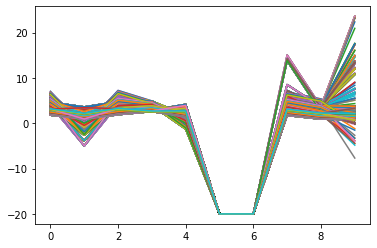

Max export violation was -0.0
Max import violation was -0.0


<Figure size 432x288 with 0 Axes>

In [13]:
aggregate_loads = scenario.aggregate_loads

# get loads as a dataframe
aggregate_loads_df = scenario.aggregate_load_df()

export_violations = []
import_violations = []
for site in scenario.sites:
    export_violations.append(site['export_violation'])
    import_violations.append(site['import_violation'])

import matplotlib.pyplot as plt

# plot the first 100 aggreate loads
plt.plot(aggregate_loads)
plt.show()

# for site in scenario.sites:
#     if site['evs'] is not None:
#         for ev in site['evs']:
#             # if ev['charge_infeasibility'] != 0.:
#             print(ev['charge_infeasibility'])


print('Max export violation was {}'.format(np.array(export_violations).max()))
print('Max import violation was {}'.format(np.array(import_violations).max()))


plt.tight_layout()
plt.show()